- To implement Linear Regression for predicting a continuous target variable.
- To implement Ridge, Lasso, and Elastic Net Regression using regularization techniques.
- To preprocess the dataset by handling missing values, categorical variables, and feature scaling.
- To perform 5-fold cross-validation and hyperparameter tuning for the regularized models.
- To evaluate the regression models using MAE, MSE, RMSE, and R² score.
- To visualize the predicted vs. actual values, residuals, feature relationships, and model coefficients.
- To analyze overfitting, underfitting, and the bias–variance trade-off.
- To compare the performance of different regression models and identify the best-performing model.

In [ ]:
# ============================================================
# EXPERIMENT 3
# REGRESSION ANALYSIS USING LINEAR AND REGULARIZED MODELS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import time
import warnings
warnings.filterwarnings("ignore")

from google.colab import files

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

from sklearn.model_selection import KFold, GridSearchCV, cross_validate

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# ============================================================
# UPLOAD DATASETS
# ============================================================

print("Upload BOTH train.csv and test.csv")

uploaded = files.upload()

print("\nUploaded files:")

for filename in uploaded.keys():
    print("-", filename)

Upload BOTH train.csv and test.csv


Saving test_Y3wMUE5_7gLdaTN.csv to test_Y3wMUE5_7gLdaTN (1).csv
Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i (1).csv

Uploaded files:
- test_Y3wMUE5_7gLdaTN (1).csv
- train_u6lujuX_CVtuZ9i (1).csv


In [ ]:
# ============================================================
# LOAD TRAIN AND TEST DATA
# ============================================================

# Find CSV files
csv_files = [
    filename for filename in uploaded.keys()
    if filename.lower().endswith(".csv")
]

print("CSV files found:")
print(csv_files)

# Automatically find train and test files
train_file = None
test_file = None

for filename in csv_files:

    name = filename.lower()

    if "train" in name:
        train_file = filename

    elif "test" in name:
        test_file = filename

print("\nTrain file:", train_file)
print("Test file :", test_file)

# If automatic detection fails
if train_file is None or test_file is None:

    print("\nCould not automatically identify train/test files.")

    train_file = input("Enter the exact TRAIN csv filename: ")
    test_file = input("Enter the exact TEST csv filename: ")

# Read datasets
train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

print("\nTraining dataset shape:", train_df.shape)
print("Testing dataset shape :", test_df.shape)

CSV files found:
['test_Y3wMUE5_7gLdaTN (1).csv', 'train_u6lujuX_CVtuZ9i (1).csv']

Train file: train_u6lujuX_CVtuZ9i (1).csv
Test file : test_Y3wMUE5_7gLdaTN (1).csv

Training dataset shape: (614, 13)
Testing dataset shape : (367, 12)


In [ ]:
# ============================================================
# VIEW DATA
# ============================================================

print("TRAINING DATA")
display(train_df.head())

print("\nTESTING DATA")
display(test_df.head())

TRAINING DATA


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y



TESTING DATA


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [ ]:
# ============================================================
# COLUMN INFORMATION
# ============================================================

print("TRAINING COLUMNS:")
print(train_df.columns.tolist())

print("\nTESTING COLUMNS:")
print(test_df.columns.tolist())

TRAINING COLUMNS:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

TESTING COLUMNS:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [ ]:
# ============================================================
# FIND TARGET COLUMN
# ============================================================

possible_targets = [
    "LoanAmount",
    "Loan_Amount",
    "Loan Amount",
    "loan_amount",
    "loan amount",
    "loanamount",
    "LoanAmountSanctioned",
    "Loan_Amount_Sanctioned",
    "loan_amount_sanctioned",
    "Amount",
    "Loan"
]

target_column = None

for col in possible_targets:

    if col in train_df.columns:
        target_column = col
        break

# If not automatically found
if target_column is None:

    print("Could not automatically identify the target column.")

    print("\nColumns in training dataset:")

    for i, col in enumerate(train_df.columns):
        print(i, ":", col)

    target_column = input(
        "\nEnter the TARGET column name exactly: "
    )

print("\nTarget column:", target_column)


Target column: LoanAmount


In [ ]:
# ============================================================
# SEPARATE FEATURES AND TARGET
# ============================================================

X_train = train_df.drop(columns=[target_column]).copy()

y_train = train_df[target_column].copy()

# Test dataset may or may not contain the target
if target_column in test_df.columns:

    X_test = test_df.drop(columns=[target_column]).copy()
    y_test = test_df[target_column].copy()

    test_has_target = True

else:

    X_test = test_df.copy()
    y_test = None

    test_has_target = False

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)

if test_has_target:
    print("y_test :", y_test.shape)
else:
    print("\nWARNING: test.csv does not contain the target column.")

X_train: (614, 12)
y_train: (614,)
X_test : (367, 11)
y_test : (367,)


In [ ]:
# ============================================================
# CLEAN TARGET VARIABLE
# ============================================================

# Convert target to numeric
y_train = pd.to_numeric(
    y_train,
    errors="coerce"
)

# Remove rows with missing target
valid_train = y_train.notna()

X_train = X_train.loc[valid_train].copy()

y_train = y_train.loc[valid_train].copy()

# Clean test target if available
if test_has_target:

    y_test = pd.to_numeric(
        y_test,
        errors="coerce"
    )

    valid_test = y_test.notna()

    X_test = X_test.loc[valid_test].copy()

    y_test = y_test.loc[valid_test].copy()

print("Training data after cleaning:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

if test_has_target:

    print("\nTesting data after cleaning:")
    print("X_test:", X_test.shape)
    print("y_test:", y_test.shape)

Training data after cleaning:
X_train: (592, 12)
y_train: (592,)

Testing data after cleaning:
X_test: (362, 11)
y_test: (362,)


In [ ]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("Training dataset information:")
train_df.info()

print("\nMissing values in training features:")
display(X_train.isnull().sum().sort_values(ascending=False))

print("\nTarget statistics:")
display(y_train.describe())

Training dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB

Missing values in training features:


,0
Credit_History,49
Self_Employed,31
Loan_Amount_Term,14
Gender,13
Dependents,13
Married,2
Loan_ID,0
Education,0
CoapplicantIncome,0
ApplicantIncome,0



Target statistics:


,LoanAmount
count,592.000000
mean,146.412162
std,85.587325
min,9.000000
25%,100.000000
50%,128.000000
75%,168.000000
max,700.000000


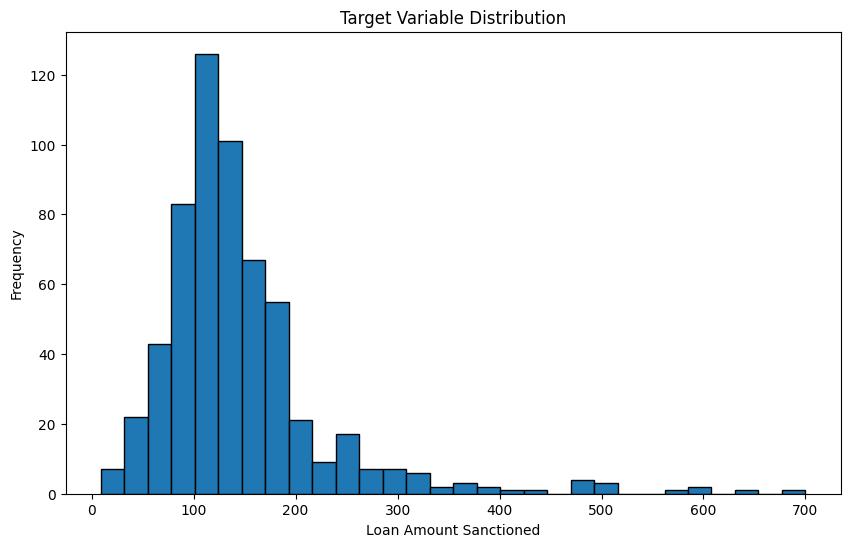

In [ ]:
# ============================================================
# TARGET VARIABLE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    y_train,
    bins=30,
    edgecolor="black"
)

plt.title("Target Variable Distribution")
plt.xlabel("Loan Amount Sanctioned")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# ============================================================
# IDENTIFY FEATURE TYPES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:",
      len(numeric_features))

print("Number of categorical features:",
      len(categorical_features))

Numerical features:
['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History']

Categorical features:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

Number of numerical features: 4
Number of categorical features: 8


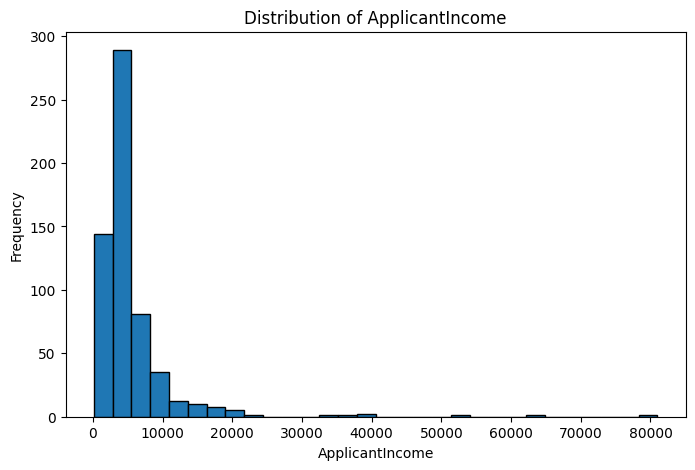

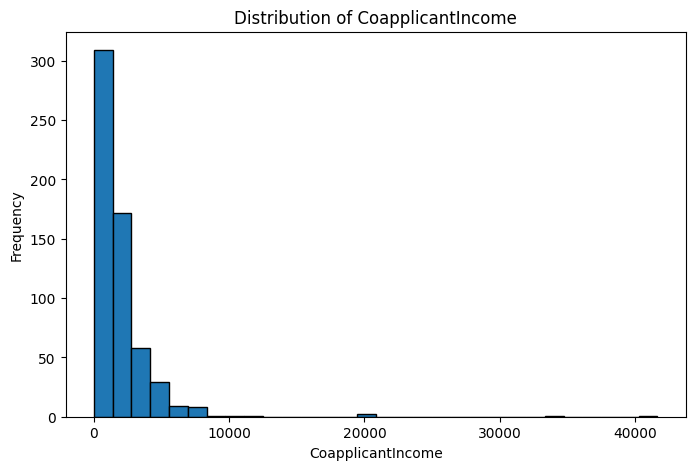

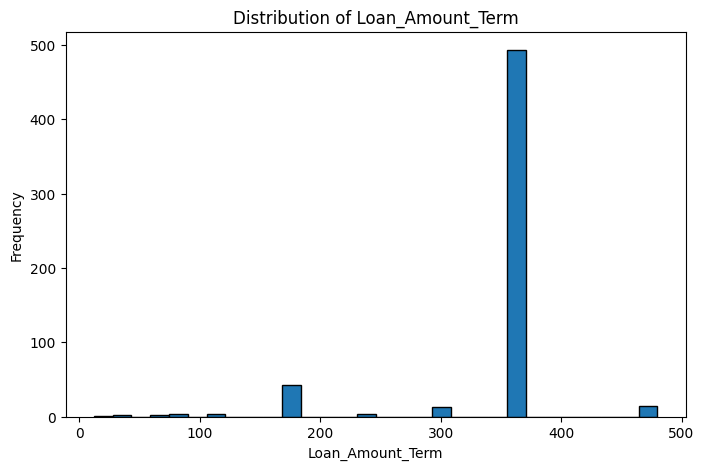

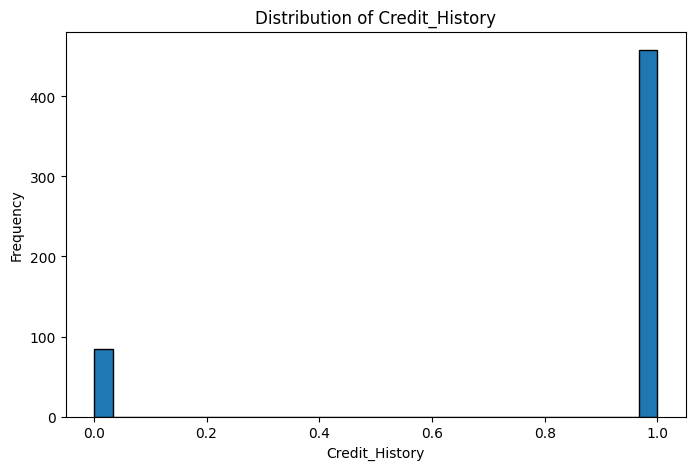

In [ ]:
# ============================================================
# NUMERICAL FEATURE DISTRIBUTIONS
# ============================================================

for col in numeric_features[:10]:

    plt.figure(figsize=(8, 5))

    plt.hist(
        X_train[col].dropna(),
        bins=30,
        edgecolor="black"
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.show()

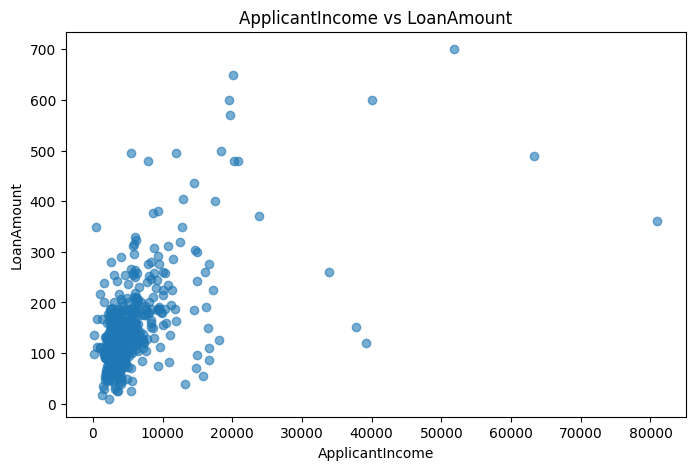

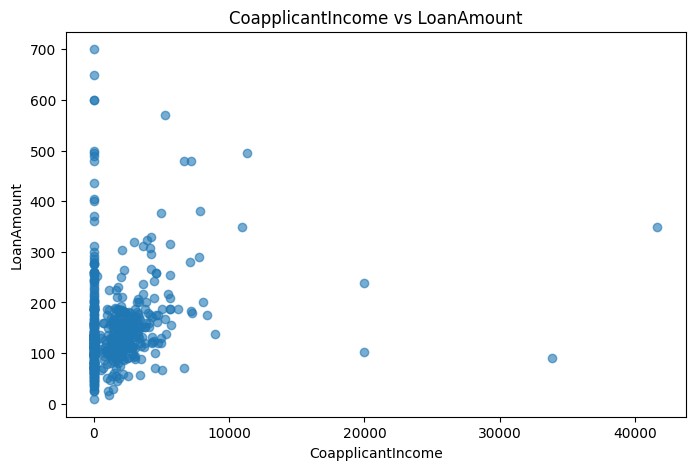

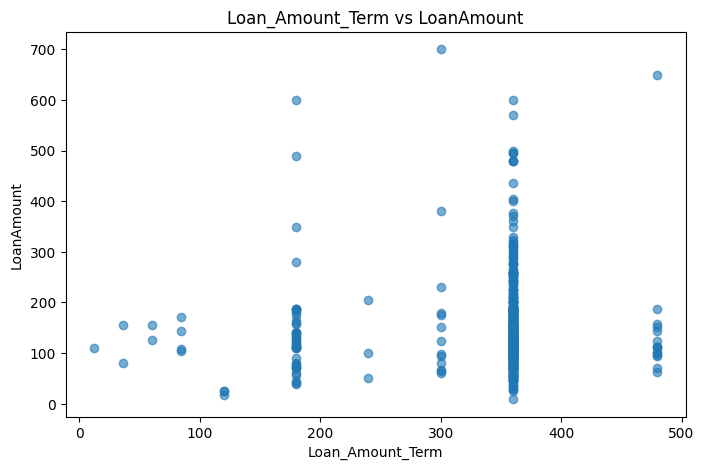

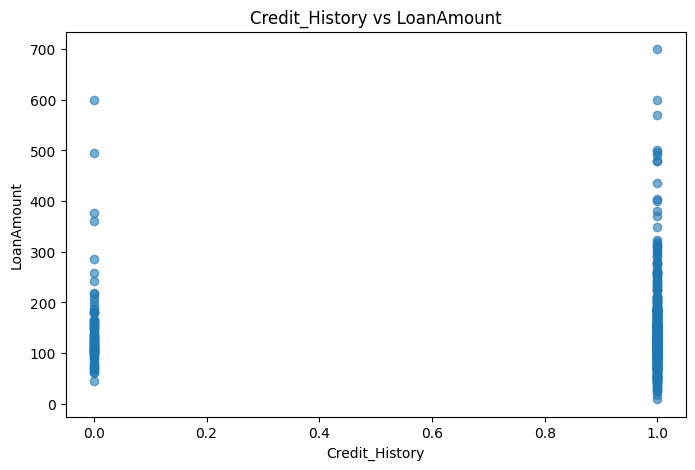

In [ ]:
# ============================================================
# FEATURE VS TARGET SCATTER PLOTS
# ============================================================

for col in numeric_features[:6]:

    temp = pd.DataFrame({
        "Feature": X_train[col],
        "Target": y_train
    }).dropna()

    plt.figure(figsize=(8, 5))

    plt.scatter(
        temp["Feature"],
        temp["Target"],
        alpha=0.6
    )

    plt.title(
        f"{col} vs {target_column}"
    )

    plt.xlabel(col)
    plt.ylabel(target_column)

    plt.show()

In [ ]:
# ============================================================
# CHECK TRAIN AND TEST COLUMNS
# ============================================================

train_columns = set(X_train.columns)
test_columns = set(X_test.columns)

missing_from_test = train_columns - test_columns
extra_in_test = test_columns - train_columns

print("Features missing from test:")
print(missing_from_test)

print("\nExtra features in test:")
print(extra_in_test)

# Keep only common columns
common_columns = [
    col for col in X_train.columns
    if col in X_test.columns
]

X_train = X_train[common_columns].copy()
X_test = X_test[common_columns].copy()

print("\nCommon feature count:", len(common_columns))
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

Features missing from test:
{'Loan_Status'}

Extra features in test:
set()

Common feature count: 11
X_train: (592, 11)
X_test : (362, 11)


In [ ]:
# ============================================================
# FINAL FEATURE TYPES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History']

Categorical features:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [ ]:
# ============================================================
# PREPROCESSING PIPELINE
# ============================================================

# Numerical preprocessing
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

# Categorical preprocessing
#
# Try sparse_output=False first.
# If older sklearn is installed, use sparse=False.

try:

    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )

except TypeError:

    categorical_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            categorical_encoder
        )
    ]
)

# Combine numerical and categorical processing
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
# ============================================================
# LINEAR REGRESSION
# ============================================================

linear_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

start_time = time.time()

linear_pipeline.fit(
    X_train,
    y_train
)

linear_training_time = time.time() - start_time

print("Linear Regression trained successfully!")

print(
    "Training time:",
    round(linear_training_time, 4),
    "seconds"
)

Linear Regression trained successfully!
Training time: 0.225 seconds


In [ ]:
# ============================================================
# LINEAR REGRESSION PREDICTIONS
# ============================================================

linear_train_pred = linear_pipeline.predict(
    X_train
)

linear_test_pred = linear_pipeline.predict(
    X_test
)

print("Training predictions:",
      len(linear_train_pred))

print("Testing predictions:",
      len(linear_test_pred))

Training predictions: 592
Testing predictions: 362


In [ ]:
# ============================================================
# 5-FOLD CROSS VALIDATION
# ============================================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-Fold Cross Validation created!")

5-Fold Cross Validation created!


In [ ]:
# ============================================================
# RIDGE REGRESSION + GRID SEARCH
# ============================================================

ridge_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            Ridge()
        )
    ]
)

ridge_params = {
    "model__alpha": [
        0.01,
        0.1,
        1,
        10,
        100
    ]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

start_time = time.time()

ridge_grid.fit(
    X_train,
    y_train
)

ridge_training_time = time.time() - start_time

print("Ridge Regression completed!")

print("\nBest parameters:")
print(ridge_grid.best_params_)

print("\nBest CV R2:")
print(ridge_grid.best_score_)

print("\nTraining time:",
      round(ridge_training_time, 4),
      "seconds")

Ridge Regression completed!

Best parameters:
{'model__alpha': 100}

Best CV R2:
0.296446410677002

Training time: 5.4762 seconds


In [ ]:
# ============================================================
# LASSO REGRESSION + GRID SEARCH
# ============================================================

lasso_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            Lasso(max_iter=10000)
        )
    ]
)

lasso_params = {
    "model__alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10
    ]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_params,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

start_time = time.time()

lasso_grid.fit(
    X_train,
    y_train
)

lasso_training_time = time.time() - start_time

print("Lasso Regression completed!")

print("\nBest parameters:")
print(lasso_grid.best_params_)

print("\nBest CV R2:")
print(lasso_grid.best_score_)

print("\nTraining time:",
      round(lasso_training_time, 4),
      "seconds")

Lasso Regression completed!

Best parameters:
{'model__alpha': 1}

Best CV R2:
0.2693085645437835

Training time: 8.6063 seconds


In [ ]:
# ============================================================
# ELASTIC NET + GRID SEARCH
# ============================================================

elastic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            ElasticNet(max_iter=10000)
        )
    ]
)

elastic_params = {
    "model__alpha": [
        0.01,
        0.1,
        1,
        10
    ],

    "model__l1_ratio": [
        0.2,
        0.5,
        0.8
    ]
}

elastic_grid = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=elastic_params,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

start_time = time.time()

elastic_grid.fit(
    X_train,
    y_train
)

elastic_training_time = time.time() - start_time

print("Elastic Net completed!")

print("\nBest parameters:")
print(elastic_grid.best_params_)

print("\nBest CV R2:")
print(elastic_grid.best_score_)

print("\nTraining time:",
      round(elastic_training_time, 4),
      "seconds")

Elastic Net completed!

Best parameters:
{'model__alpha': 1, 'model__l1_ratio': 0.8}

Best CV R2:
0.2919132541134022

Training time: 2.5264 seconds


In [ ]:
# ============================================================
# PREDICTIONS FROM ALL MODELS
# ============================================================

ridge_train_pred = ridge_grid.predict(
    X_train
)

ridge_test_pred = ridge_grid.predict(
    X_test
)

lasso_train_pred = lasso_grid.predict(
    X_train
)

lasso_test_pred = lasso_grid.predict(
    X_test
)

elastic_train_pred = elastic_grid.predict(
    X_train
)

elastic_test_pred = elastic_grid.predict(
    X_test
)

print("All model predictions generated!")

All model predictions generated!


In [ ]:
# ============================================================
# EVALUATION FUNCTION
# ============================================================

def calculate_metrics(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mae, mse, rmse, r2

In [ ]:
# ============================================================
# TEST SET PERFORMANCE
# ============================================================

if not test_has_target:

    print(
        "The test dataset does not contain the target column."
    )

    print(
        "Therefore, test-set metrics cannot be calculated."
    )

else:

    results = []

    model_predictions = {

        "Linear Regression": (
            linear_test_pred,
            linear_training_time
        ),

        "Ridge Regression": (
            ridge_test_pred,
            ridge_training_time
        ),

        "Lasso Regression": (
            lasso_test_pred,
            lasso_training_time
        ),

        "Elastic Net Regression": (
            elastic_test_pred,
            elastic_training_time
        )
    }

    for model_name, (
        predictions,
        training_time
    ) in model_predictions.items():

        mae, mse, rmse, r2 = calculate_metrics(
            y_test,
            predictions
        )

        results.append({

            "Model": model_name,

            "MAE": mae,

            "MSE": mse,

            "RMSE": rmse,

            "R2 Score": r2,

            "Training Time (sec)": training_time
        })

    test_results = pd.DataFrame(
        results
    )

    display(test_results)

,Model,MAE,MSE,RMSE,R2 Score,Training Time (sec)
0,Linear Regression,36.046739,2728.887322,52.238753,0.273355,0.224954
1,Ridge Regression,35.757730,2606.455184,51.053454,0.305956,5.476215
2,Lasso Regression,35.440016,2660.134113,51.576488,0.291663,8.606272
3,Elastic Net Regression,35.765292,2587.473415,50.867214,0.311011,2.526368


In [ ]:
# ============================================================
# 5-FOLD CROSS VALIDATION PERFORMANCE
# ============================================================

models_for_cv = {

    "Linear Regression":
        linear_pipeline,

    "Ridge Regression":
        ridge_grid.best_estimator_,

    "Lasso Regression":
        lasso_grid.best_estimator_,

    "Elastic Net Regression":
        elastic_grid.best_estimator_
}

cv_results = []

for name, model in models_for_cv.items():

    scores = cross_validate(

        model,

        X_train,

        y_train,

        cv=cv,

        scoring={
            "MAE":
                "neg_mean_absolute_error",

            "MSE":
                "neg_mean_squared_error",

            "R2":
                "r2"
        },

        n_jobs=-1
    )

    mae = -scores[
        "test_MAE"
    ].mean()

    mse = -scores[
        "test_MSE"
    ].mean()

    rmse = np.sqrt(mse)

    r2 = scores[
        "test_R2"
    ].mean()

    cv_results.append({

        "Model": name,

        "MAE": mae,

        "MSE": mse,

        "RMSE": rmse,

        "R2": r2
    })

cv_results_df = pd.DataFrame(
    cv_results
)

display(cv_results_df)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,42.739866,5362.211808,73.227125,0.262941
1,Ridge Regression,43.391865,5026.373200,70.896920,0.296446
2,Lasso Regression,42.594031,5323.237811,72.960522,0.269309
3,Elastic Net Regression,43.594158,5061.042596,71.141005,0.291913


In [ ]:
# ============================================================
# HYPERPARAMETER TUNING SUMMARY
# ============================================================

tuning_summary = pd.DataFrame({

    "Model": [

        "Ridge Regression",

        "Lasso Regression",

        "Elastic Net Regression"
    ],

    "Search Method": [

        "Grid Search",

        "Grid Search",

        "Grid Search"
    ],

    "Best Parameters": [

        str(
            ridge_grid.best_params_
        ),

        str(
            lasso_grid.best_params_
        ),

        str(
            elastic_grid.best_params_
        )
    ],

    "Best CV R2": [

        ridge_grid.best_score_,

        lasso_grid.best_score_,

        elastic_grid.best_score_
    ]
})

display(tuning_summary)

,Model,Search Method,Best Parameters,Best CV R2
0,Ridge Regression,Grid Search,{'model__alpha': 100},0.296446
1,Lasso Regression,Grid Search,{'model__alpha': 1},0.269309
2,Elastic Net Regression,Grid Search,"{'model__alpha': 1, 'model__l1_ratio': 0.8}",0.291913


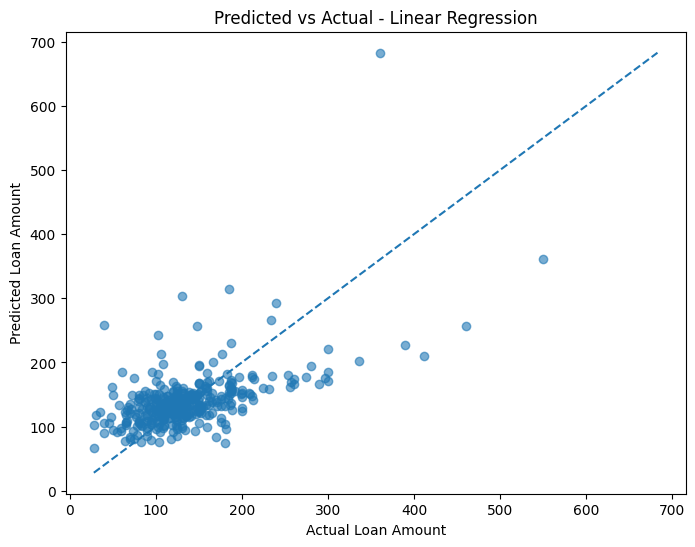

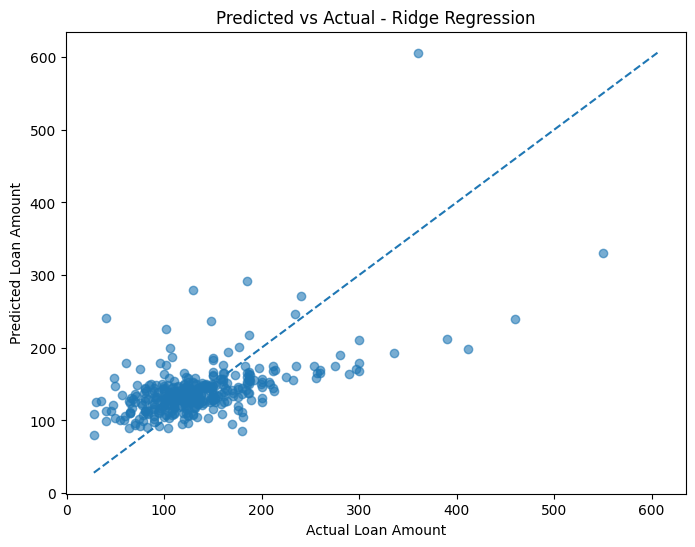

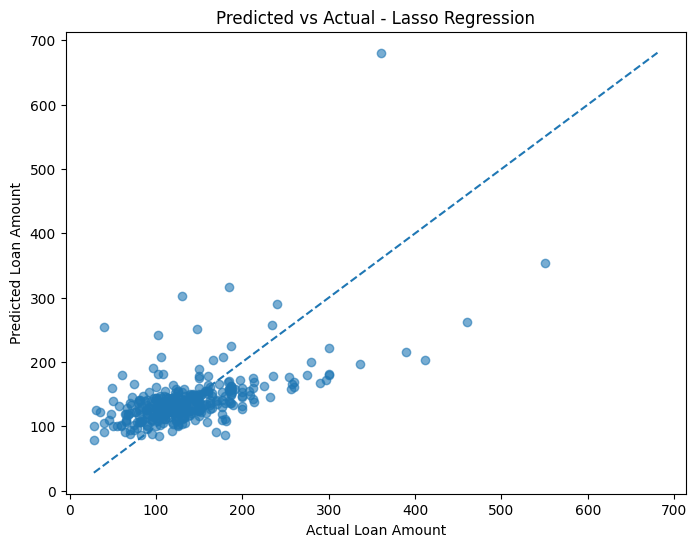

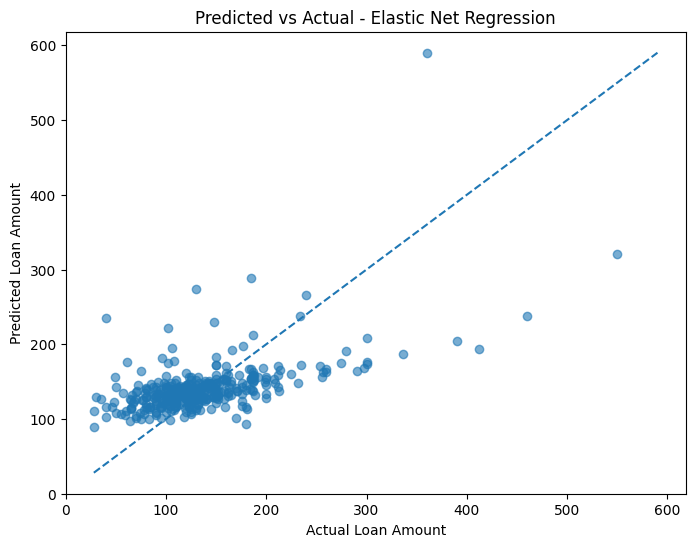

In [ ]:
# ============================================================
# PREDICTED VS ACTUAL VALUES
# ============================================================

if test_has_target:

    predictions_dict = {

        "Linear Regression":
            linear_test_pred,

        "Ridge Regression":
            ridge_test_pred,

        "Lasso Regression":
            lasso_test_pred,

        "Elastic Net Regression":
            elastic_test_pred
    }

    for name, predictions in predictions_dict.items():

        plt.figure(figsize=(8, 6))

        plt.scatter(
            y_test,
            predictions,
            alpha=0.6
        )

        minimum = min(
            y_test.min(),
            predictions.min()
        )

        maximum = max(
            y_test.max(),
            predictions.max()
        )

        plt.plot(
            [minimum, maximum],
            [minimum, maximum],
            linestyle="--"
        )

        plt.title(
            f"Predicted vs Actual - {name}"
        )

        plt.xlabel(
            "Actual Loan Amount"
        )

        plt.ylabel(
            "Predicted Loan Amount"
        )

        plt.show()

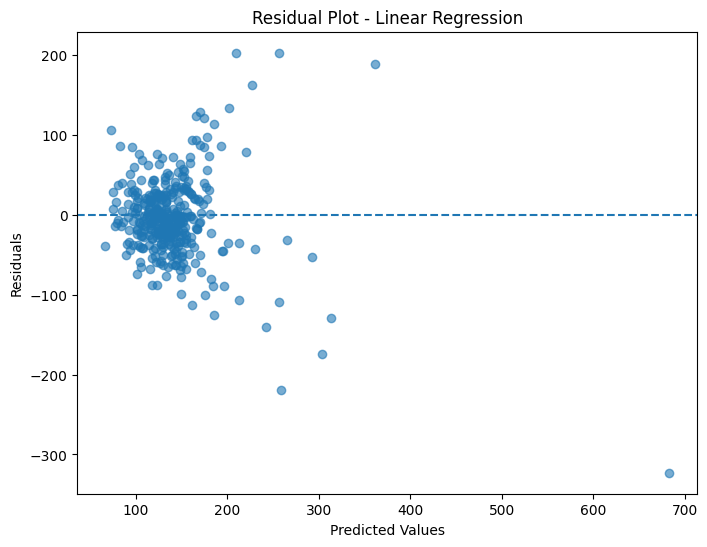

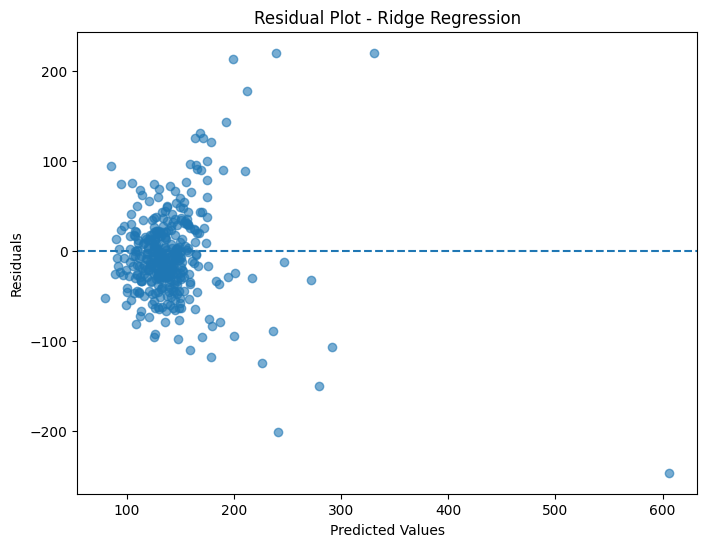

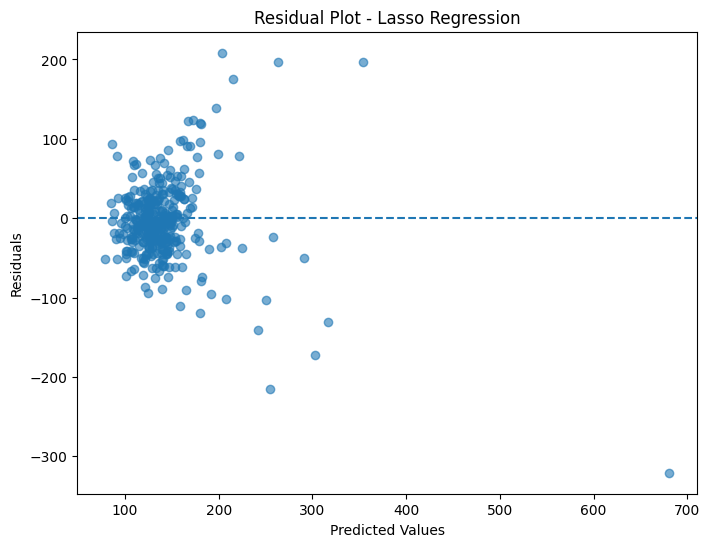

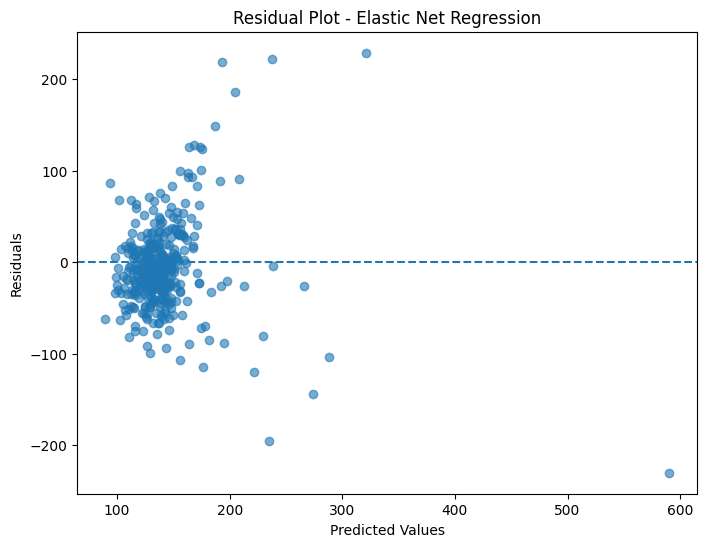

In [ ]:
# ============================================================
# RESIDUAL PLOTS
# ============================================================

if test_has_target:

    for name, predictions in predictions_dict.items():

        residuals = (
            y_test - predictions
        )

        plt.figure(figsize=(8, 6))

        plt.scatter(
            predictions,
            residuals,
            alpha=0.6
        )

        plt.axhline(
            0,
            linestyle="--"
        )

        plt.title(
            f"Residual Plot - {name}"
        )

        plt.xlabel(
            "Predicted Values"
        )

        plt.ylabel(
            "Residuals"
        )

        plt.show()

,Model,Training MSE,Test MSE
0,Linear Regression,2.379378e-25,2728.887322
1,Ridge Regression,4.204021e+03,2606.455184
2,Lasso Regression,4.247414e+03,2660.134113
3,Elastic Net Regression,4.363820e+03,2587.473415


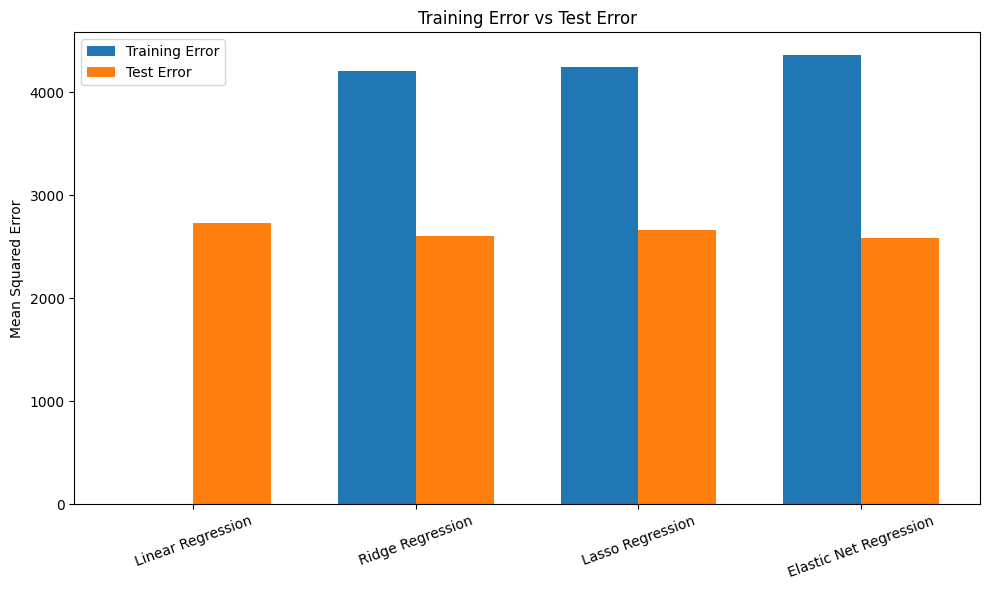

In [ ]:
# ============================================================
# TRAINING ERROR VS TEST ERROR
# ============================================================

if test_has_target:

    error_results = []

    all_models = {

        "Linear Regression": (
            linear_train_pred,
            linear_test_pred
        ),

        "Ridge Regression": (
            ridge_train_pred,
            ridge_test_pred
        ),

        "Lasso Regression": (
            lasso_train_pred,
            lasso_test_pred
        ),

        "Elastic Net Regression": (
            elastic_train_pred,
            elastic_test_pred
        )
    }

    for name, (
        train_pred,
        test_pred
    ) in all_models.items():

        train_mse = mean_squared_error(
            y_train,
            train_pred
        )

        test_mse = mean_squared_error(
            y_test,
            test_pred
        )

        error_results.append({

            "Model": name,

            "Training MSE": train_mse,

            "Test MSE": test_mse
        })

    error_df = pd.DataFrame(
        error_results
    )

    display(error_df)

    # Plot

    x = np.arange(
        len(error_df)
    )

    width = 0.35

    plt.figure(figsize=(10, 6))

    plt.bar(
        x - width / 2,
        error_df["Training MSE"],
        width,
        label="Training Error"
    )

    plt.bar(
        x + width / 2,
        error_df["Test MSE"],
        width,
        label="Test Error"
    )

    plt.xticks(
        x,
        error_df["Model"],
        rotation=20
    )

    plt.ylabel(
        "Mean Squared Error"
    )

    plt.title(
        "Training Error vs Test Error"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

In [ ]:
# ============================================================
# COEFFICIENT COMPARISON
# ============================================================

# Get transformed feature names

fitted_preprocessor = (
    linear_pipeline
    .named_steps["preprocessor"]
)

feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

# Get coefficients

linear_coef = (
    linear_pipeline
    .named_steps["model"]
    .coef_
)

ridge_coef = (
    ridge_grid
    .best_estimator_
    .named_steps["model"]
    .coef_
)

lasso_coef = (
    lasso_grid
    .best_estimator_
    .named_steps["model"]
    .coef_
)

elastic_coef = (
    elastic_grid
    .best_estimator_
    .named_steps["model"]
    .coef_
)

coefficient_df = pd.DataFrame({

    "Feature": feature_names,

    "Linear": linear_coef,

    "Ridge": ridge_coef,

    "Lasso": lasso_coef,

    "Elastic Net": elastic_coef
})

print("Coefficient comparison:")
display(
    coefficient_df.head(20)
)

Coefficient comparison:


,Feature,Linear,Ridge,Lasso,Elastic Net
0,num__ApplicantIncome,48.752047,41.880359,49.036113,40.614023
1,num__CoapplicantIncome,20.956828,17.341279,20.351047,16.269193
2,num__Loan_Amount_Term,7.846134,6.083092,6.504035,4.974617
3,num__Credit_History,0.333087,0.247916,0.000000,0.000000
4,cat__Loan_ID_LP001003,-35.804565,-0.300446,-0.000000,-0.000000
5,cat__Loan_ID_LP001005,-60.399857,-0.630467,-0.000000,-0.000000
6,cat__Loan_ID_LP001006,7.538557,0.000281,-0.000000,-0.000000
7,cat__Loan_ID_LP001008,15.921477,0.104602,0.000000,0.000000
8,cat__Loan_ID_LP001011,83.551350,0.884153,0.000000,0.000000
9,cat__Loan_ID_LP001013,-9.531611,-0.181657,-0.000000,-0.000000


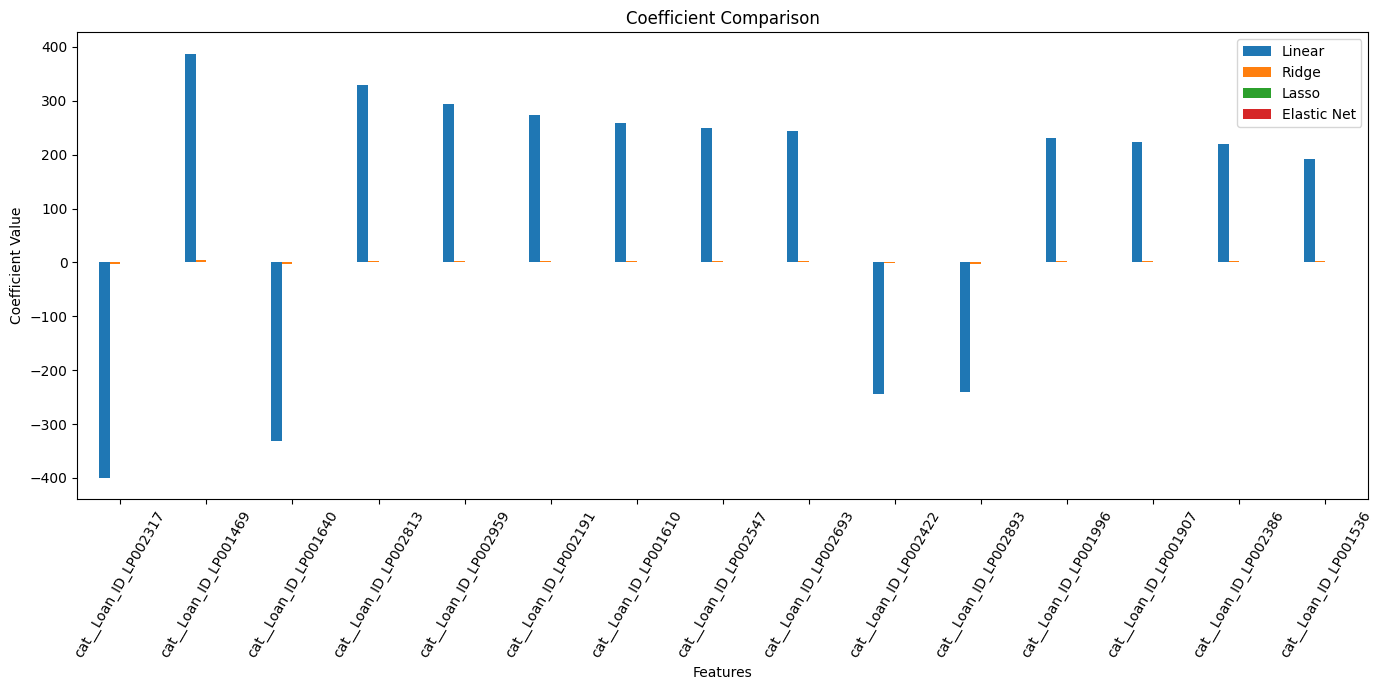

In [ ]:
# ============================================================
# COEFFICIENT COMPARISON BAR PLOT
# ============================================================

coefficient_df["Absolute Linear"] = (
    coefficient_df["Linear"].abs()
)

top_features = (
    coefficient_df
    .sort_values(
        "Absolute Linear",
        ascending=False
    )
    .head(15)
)

plot_df = top_features[
    [
        "Feature",
        "Linear",
        "Ridge",
        "Lasso",
        "Elastic Net"
    ]
].set_index("Feature")

plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Coefficient Comparison"
)

plt.xlabel(
    "Features"
)

plt.ylabel(
    "Coefficient Value"
)

plt.xticks(
    rotation=60
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# LASSO FEATURE SPARSITY
# ============================================================

zero_lasso = np.sum(
    np.isclose(
        lasso_coef,
        0
    )
)

total_features = len(
    lasso_coef
)

percentage_zero = (
    zero_lasso /
    total_features *
    100
)

print(
    "Total transformed features:",
    total_features
)

print(
    "Zero Lasso coefficients:",
    zero_lasso
)

print(
    "Percentage of zero coefficients:",
    round(percentage_zero, 2),
    "%"
)

Total transformed features: 611
Zero Lasso coefficients: 602
Percentage of zero coefficients: 98.53 %


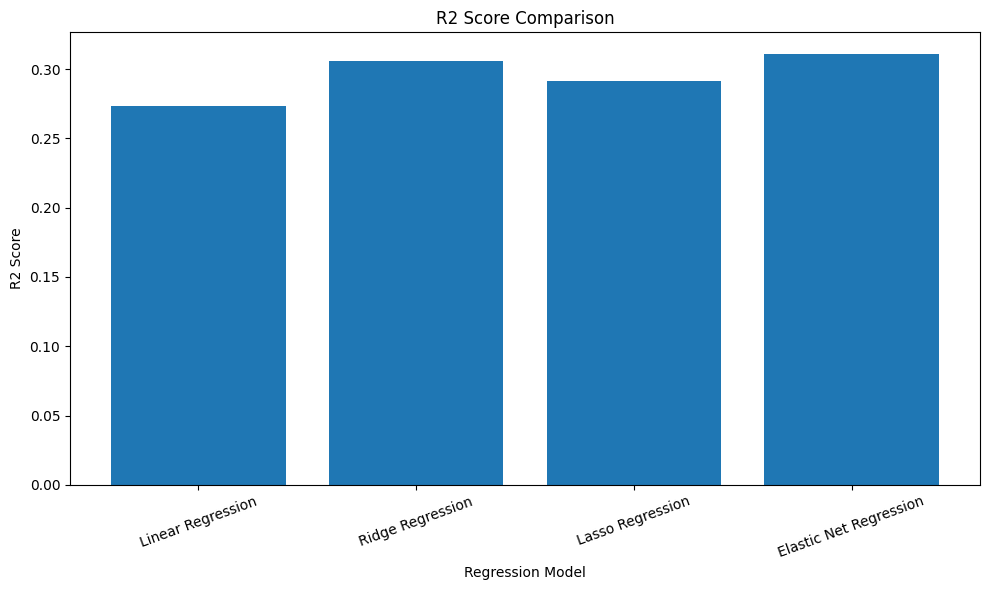

In [ ]:
# ============================================================
# MODEL R2 COMPARISON
# ============================================================

if test_has_target:

    plt.figure(figsize=(10, 6))

    plt.bar(
        test_results["Model"],
        test_results["R2 Score"]
    )

    plt.title(
        "R2 Score Comparison"
    )

    plt.xlabel(
        "Regression Model"
    )

    plt.ylabel(
        "R2 Score"
    )

    plt.xticks(
        rotation=20
    )

    plt.tight_layout()

    plt.show()

In [ ]:
# ============================================================
# BEST MODEL
# ============================================================

if test_has_target:

    best_index = (
        test_results["R2 Score"]
        .idxmax()
    )

    best_model = test_results.loc[
        best_index,
        "Model"
    ]

    best_r2 = test_results.loc[
        best_index,
        "R2 Score"
    ]

    print(
        "Best model:",
        best_model
    )

    print(
        "Best Test R2:",
        round(best_r2, 4)
    )

else:

    print(
        "Test target is unavailable."
    )

    print(
        "Use cross-validation R2 to compare models."
    )

Best model: Elastic Net Regression
Best Test R2: 0.311


In [ ]:
# ============================================================
# OBSERVATIONS
# ============================================================

print("=" * 70)
print("EXPERIMENT 3 - OBSERVATIONS")
print("=" * 70)

print("""
1. Linear Regression was implemented as the baseline regression model.

2. Ridge Regression was implemented to reduce the magnitude of
   regression coefficients and control model complexity.

3. Lasso Regression was implemented to perform regularization
   and feature selection by shrinking some coefficients toward zero.

4. Elastic Net Regression combines the properties of Ridge and
   Lasso regularization.

5. Missing numerical values were handled using median imputation.

6. Missing categorical values were handled using the most frequent
   category.

7. Numerical features were standardized before model training.

8. Categorical features were converted into numerical form using
   one-hot encoding.

9. Five-fold cross-validation was used for model evaluation and
   hyperparameter selection.

10. Grid Search was used to identify suitable regularization
    parameters for Ridge, Lasso, and Elastic Net.

11. Model performance was evaluated using MAE, MSE, RMSE and R2 score.

12. Predicted-versus-actual plots were used to examine the agreement
    between predicted and actual loan amounts.

13. Residual plots were used to analyze prediction errors.

14. Training and test errors were compared to identify possible
    overfitting or underfitting.

15. Coefficient comparison was performed to study the effect of
    regularization on model coefficients.

16. Lasso coefficient sparsity was analyzed to determine the number
    of coefficients reduced to zero.
""")

EXPERIMENT 3 - OBSERVATIONS

1. Linear Regression was implemented as the baseline regression model.

2. Ridge Regression was implemented to reduce the magnitude of
   regression coefficients and control model complexity.

3. Lasso Regression was implemented to perform regularization
   and feature selection by shrinking some coefficients toward zero.

4. Elastic Net Regression combines the properties of Ridge and
   Lasso regularization.

5. Missing numerical values were handled using median imputation.

6. Missing categorical values were handled using the most frequent
   category.

7. Numerical features were standardized before model training.

8. Categorical features were converted into numerical form using
   one-hot encoding.

9. Five-fold cross-validation was used for model evaluation and
   hyperparameter selection.

10. Grid Search was used to identify suitable regularization
    parameters for Ridge, Lasso, and Elastic Net.

11. Model performance was evaluated using MAE, MSE, 

In [ ]:
# ============================================================
# FINAL RESULTS TABLE
# ============================================================

if test_has_target:

    print("=" * 70)
    print("FINAL TEST SET RESULTS")
    print("=" * 70)

    display(
        test_results.style.format({
            "MAE": "{:.4f}",
            "MSE": "{:.4f}",
            "RMSE": "{:.4f}",
            "R2 Score": "{:.4f}",
            "Training Time (sec)": "{:.4f}"
        })
    )

print("\n")
print("=" * 70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    cv_results_df.style.format({
        "MAE": "{:.4f}",
        "MSE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}"
    })
)

print("\n")
print("=" * 70)
print("HYPERPARAMETER RESULTS")
print("=" * 70)

display(tuning_summary)

FINAL TEST SET RESULTS


,Model,MAE,MSE,RMSE,R2 Score,Training Time (sec)
0,Linear Regression,36.0467,2728.8873,52.2388,0.2734,0.2250
1,Ridge Regression,35.7577,2606.4552,51.0535,0.3060,5.4762
2,Lasso Regression,35.4400,2660.1341,51.5765,0.2917,8.6063
3,Elastic Net Regression,35.7653,2587.4734,50.8672,0.3110,2.5264




5-FOLD CROSS-VALIDATION RESULTS


,Model,MAE,MSE,RMSE,R2
0,Linear Regression,42.7399,5362.2118,73.2271,0.2629
1,Ridge Regression,43.3919,5026.3732,70.8969,0.2964
2,Lasso Regression,42.5940,5323.2378,72.9605,0.2693
3,Elastic Net Regression,43.5942,5061.0426,71.1410,0.2919




HYPERPARAMETER RESULTS


,Model,Search Method,Best Parameters,Best CV R2
0,Ridge Regression,Grid Search,{'model__alpha': 100},0.296446
1,Lasso Regression,Grid Search,{'model__alpha': 1},0.269309
2,Elastic Net Regression,Grid Search,"{'model__alpha': 1, 'model__l1_ratio': 0.8}",0.291913


In [ ]:
# ============================================================
# SAVE RESULTS
# ============================================================

if test_has_target:

    test_results.to_csv(
        "Experiment3_Test_Performance.csv",
        index=False
    )

cv_results_df.to_csv(
    "Experiment3_CV_Performance.csv",
    index=False
)

tuning_summary.to_csv(
    "Experiment3_Hyperparameter_Tuning.csv",
    index=False
)

coefficient_df.to_csv(
    "Experiment3_Coefficients.csv",
    index=False
)

print("All result files have been saved!")

All result files have been saved!
